# MLP Neural Network — Fake News Detection 

Ky notebook shton **Multi-Layer Perceptron (MLP)** si algoritëm i pestë, duke përdorur **të njëjtat splits dhe vectorizer** si `eda.ipynb`.


## 1. Importet

In [10]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    f1_score, precision_score, recall_score
)

print('Importet u ngarkuan.')

Importet u ngarkuan.


## 2. Ngarko splits dhe vectorizer nga eda.ipynb

> **Kushti:** `eda.ipynb` duhet të ketë ekzekutuar së pari, pasi kërkohen  
> `../data/splits/` dhe `../models/tfidf_vectorizer.pkl`.


In [11]:
# Ngarko splits — identike me eda.ipynb
X_train = pd.read_csv('../data/splits/X_train.csv').squeeze('columns')
X_test  = pd.read_csv('../data/splits/X_test.csv').squeeze('columns')
y_train = pd.read_csv('../data/splits/y_train.csv').squeeze('columns')
y_test  = pd.read_csv('../data/splits/y_test.csv').squeeze('columns')

print(f'Train: {len(X_train):,} shembuj')
print(f'Test:  {len(X_test):,} shembuj')
print(f'Shperndarje test: {dict(y_test.value_counts())}')

Train: 57,676 shembuj
Test:  14,419 shembuj
Shperndarje test: {1: 7413, 0: 7006}


In [12]:
# Ngarkohet vectorizer-i i njejte 
# stop_words='english', max_df=0.7
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Matrica TF-IDF (origjinale, perdoret nga LR/NB/SVM/RF): '
      f'{X_train_tfidf.shape[0]:,} x {X_train_tfidf.shape[1]:,}')

Matrica TF-IDF (origjinale, perdoret nga LR/NB/SVM/RF): 57,676 x 220,275


## 3. Optimizimi: Chi-square Feature Selection (vetem per MLP)

**Problemi:** Matrica TF-IDF ka ~220k kolona. Shtresa e pare e MLP (`hidden_layer_sizes[0]`) krijon nje matrice peshash me permasa `n_features x n_neurons_1`. Me 220,275 veçori dhe 128 neurone, vetem shtresa e pare ka ~28.2 milion parametra (+ Adam optimizer mban edhe `m` dhe `v` per cdo parameter, pra ~3x me shume memorie). Kjo eshte burimi kryesor i kohes se trajnimit dhe RAM-it te konsumuar.

**Zgjidhja:** `SelectKBest` me `chi2` punon direkt mbi matrica sparse jo-negative (si TF-IDF) ne nje kalim te vetem, pa kerkuar konvertim ne dense (ndryshe nga PCA/TruncatedSVD klasike te perdorura naivisht, te cilat per matrica kaq te medha do te kerkonin shume me shume RAM dhe kohe per SVD-ne e plote). `chi2` vlerëson varësinë statistikore te çdo fjale me etiketen (fake/real) dhe mban vetem fjalet me te dobishme.

**Vlera e zgjedhur:** `k=30000` — reduktim ~7.3x i dimensionalitetit, duke mbajtur shumicen e sinjalit (fjalet shume te rralla qe shfaqen ne 1-2 dokumente kontribuojne minimalisht ne pikët chi2 dhe shpesh shkaktojne overfitting).

In [13]:
N_BEST_FEATURES = 30_000  # ~220k -> 30k kolona (~7.3x reduktim), vetem per MLP

selector = SelectKBest(score_func=chi2, k=N_BEST_FEATURES)
X_train_mlp = selector.fit_transform(X_train_tfidf, y_train)
X_test_mlp  = selector.transform(X_test_tfidf)

X_train_mlp = X_train_mlp.astype(np.float32)
X_test_mlp  = X_test_mlp.astype(np.float32)

print(f'Para selektimit: {X_train_tfidf.shape}')
print(f'Pas selektimit:  {X_train_mlp.shape}  (dtype={X_train_mlp.dtype})')

# Ruaj selector-in — i nevojshem per te riprodhuar/perdorur modelin MLP me vone
joblib.dump(selector, '../models/chi2_selector_mlp.pkl')

gc.collect()

Para selektimit: (57676, 220275)
Pas selektimit:  (57676, 30000)  (dtype=float32)


13810

## 4. Arkitektura dhe Hiperparametrat e MLP 

```
  Hyrja (TF-IDF + chi2, 30,000 veçori)
         |
  Hidden Layer 1: 128 neurone — ReLU
         |
  Hidden Layer 2:  64 neurone — ReLU
         |
  Dalja: 2 klasa (0=Real, 1=Fake)
```

| Parametër | Vlera | Arsyeja |
|---|---|---|
| `hidden_layer_sizes` | `(128, 64)` | E mjaftueshme per 30k veçori; shtresa me e madhe (256+) shton kohe trajnimi pa perfitim te dukshem mbi te dhena te rralla TF-IDF |
| `activation` | `relu` | Shmang vanishing gradient, llogaritje e shpejte (max(0,x)) |
| `solver` | `adam` | Konvergjence me e shpejte se SGD per te dhena sparse me shume veçori; `lbfgs` nuk shkallezohet mire per >10k mostra |
| `alpha` | `0.0003` | L2 regularizim, pak me i larte se default sepse chi2 zgjedh tashme veçorite me te mira (rrezik me i ulet overfitting, por nevojitet stabilitet) |
| `batch_size` | `512` | Batch me i madh shfrytezon mire BLAS/Accelerate ne Apple Silicon (vektorizim SIMD), redukton numrin e update-ve per epoke krahasuar me 256 |
| `learning_rate` | `adaptive` | Ul learning rate automatikisht nese humbja nuk permiresohet, shmang divergjencen |
| `learning_rate_init` | `0.002` | Pak me i larte se default (0.001) per konvergjence me te shpejte me batch_size me te madh |
| `max_iter` | `40` | Kufi i sigurise; me early_stopping zakonisht ndalon shume me pare |
| `early_stopping` | `True` | Ndalon trajnimin kur humbja e validimit nuk permiresohet — kursim direkt kohe |
| `validation_fraction` | `0.1` | 10% e train per monitorim te early stopping |
| `n_iter_no_change` | `4` | Me pak durim se default (10) — ndalon me shpejt pasi konvergjenca eshte tashme e shpejte me veçori te reduktuara |
| `tol` | `1e-4` | Pragu i permiresimit minimal per te konsideruar nje epoke 'progres' |
| `shuffle` | `True` | Rendisje rastesisht e mostrave per cdo epoke (default, ruajtur per stabilitet stokastik) |
| `random_state` | `42` | Riprodhueshmeri e plote |

## 5. Trajnimi i MLP

In [14]:
print('Duke trajnuar MLP Neural Network (optimizuar)...')

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0003,
    batch_size=512,
    learning_rate='adaptive',
    learning_rate_init=0.002,
    max_iter=40,
    tol=1e-4,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=4,
    shuffle=True,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train_mlp, y_train)

print(f'Trajnimi perfundoi!')
print(f'Iteracione: {mlp_model.n_iter_}')
print(f'Humbja finale: {mlp_model.loss_:.6f}')

joblib.dump(mlp_model, '../models/mlp_model.pkl')
print('Modeli u ruajt: ../models/mlp_model.pkl')

Duke trajnuar MLP Neural Network (optimizuar)...
Iteration 1, loss = 0.23481146
Validation score: 0.958218
Iteration 2, loss = 0.06259627
Validation score: 0.964979
Iteration 3, loss = 0.02758579
Validation score: 0.963592
Iteration 4, loss = 0.01273042
Validation score: 0.961859
Iteration 5, loss = 0.00626820
Validation score: 0.963592
Iteration 6, loss = 0.00377794
Validation score: 0.964112
Iteration 7, loss = 0.00297158
Validation score: 0.964459
Validation score did not improve more than tol=0.000100 for 4 consecutive epochs. Stopping.
Trajnimi perfundoi!
Iteracione: 7
Humbja finale: 0.002972
Modeli u ruajt: ../models/mlp_model.pkl


## 6. Kurba e humbjes gjate trajnimit

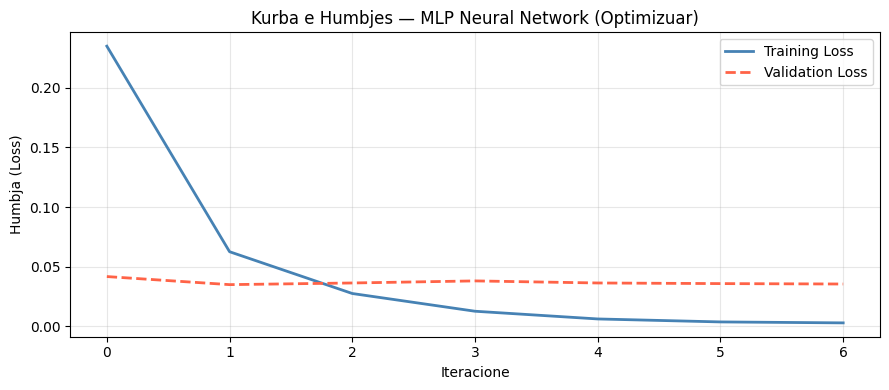

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue', linewidth=2, label='Training Loss')

if mlp_model.validation_scores_ is not None:
    val_loss = [1 - s for s in mlp_model.validation_scores_]
    plt.plot(val_loss, color='tomato', linewidth=2, linestyle='--', label='Validation Loss')

plt.xlabel('Iteracione')
plt.ylabel('Humbja (Loss)')
plt.title('Kurba e Humbjes — MLP Neural Network (Optimizuar)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/mlp_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Vleresimi

In [16]:
y_pred_mlp = mlp_model.predict(X_test_mlp)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

print('MLP Accuracy:', accuracy_mlp)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.957417296622512

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7006
           1       0.96      0.96      0.96      7413

    accuracy                           0.96     14419
   macro avg       0.96      0.96      0.96     14419
weighted avg       0.96      0.96      0.96     14419



## 8. Confusion Matrix

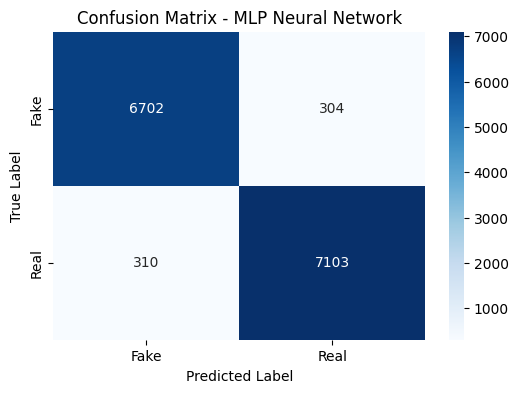

In [17]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)
plt.title('Confusion Matrix - MLP Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../figures/confusion_matrix_mlp.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. ROC Curve — te 5 modelet bashke

Shenim: LR, NB, SVM, RF perdorin matricen origjinale `X_test_tfidf` (220k veçori, e pandryshuar), ndersa MLP perdor `X_test_mlp` (30k veçori pas chi2). Kjo eshte e qellimshme — vetem MLP perfiton nga feature selection, modelet e tjera mbeten plotesisht identike me `eda.ipynb`.

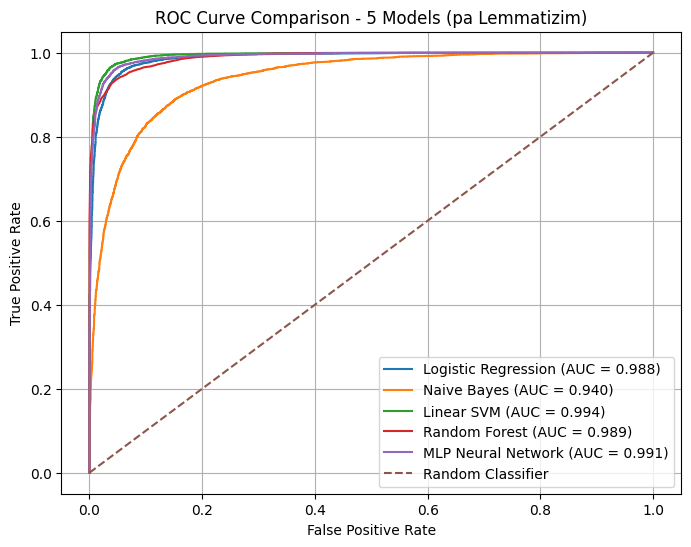

In [18]:
# Ngarko 4 modelet ekzistuese
log_reg   = joblib.load('../models/logistic_regression.pkl')
nb_model  = joblib.load('../models/naive_bayes.pkl')
svm_model = joblib.load('../models/linear_svm.pkl')
rf_model  = joblib.load('../models/random_forest.pkl')

y_score_lr  = log_reg.predict_proba(X_test_tfidf)[:, 1]
y_score_nb  = nb_model.predict_proba(X_test_tfidf)[:, 1]
y_score_svm = svm_model.decision_function(X_test_tfidf)
y_score_rf  = rf_model.predict_proba(X_test_tfidf)[:, 1]
y_score_mlp = mlp_model.predict_proba(X_test_mlp)[:, 1]

models_scores = {
    'Logistic Regression': y_score_lr,
    'Naive Bayes':         y_score_nb,
    'Linear SVM':          y_score_svm,
    'Random Forest':       y_score_rf,
    'MLP Neural Network':  y_score_mlp,
}

plt.figure(figsize=(8, 6))
for name, score in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - 5 Models (pa Lemmatizim)')
plt.legend()
plt.grid(True)
plt.savefig('../figures/roc_curves_5models.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Tabela krahasuese — 5 modelet

In [19]:
y_pred_lr  = log_reg.predict(X_test_tfidf)
y_pred_nb  = nb_model.predict(X_test_tfidf)
y_pred_svm = svm_model.predict(X_test_tfidf)
y_pred_rf  = rf_model.predict(X_test_tfidf)

def get_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'AUC':       round(roc_auc_score(y_true, y_score), 4),
    }

results_no_lemma = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr,  y_score_lr),
    'Naive Bayes':         get_metrics(y_test, y_pred_nb,  y_score_nb),
    'Linear SVM':          get_metrics(y_test, y_pred_svm, y_score_svm),
    'Random Forest':       get_metrics(y_test, y_pred_rf,  y_score_rf),
    'MLP Neural Network':  get_metrics(y_test, y_pred_mlp, y_score_mlp),
}).T.sort_values('Accuracy', ascending=False)

print('=== 5 MODELET — PA LEMMATIZIM ===')
print(results_no_lemma.to_string())

# Ruaj per lemmatizer_comparison.ipynb
results_no_lemma.to_csv('../data/results_no_lemmatization.csv')
print('\nRezultatet u ruajten: ../data/results_no_lemmatization.csv')
print('Hapi tjeter: ekzekuto lemmatizer_comparison.ipynb')

# Pastrim memorie final
gc.collect()

=== 5 MODELET — PA LEMMATIZIM ===
                     Accuracy      F1  Precision  Recall     AUC
Linear SVM             0.9634  0.9634     0.9635  0.9634  0.9936
MLP Neural Network     0.9574  0.9574     0.9574  0.9574  0.9909
Logistic Regression    0.9490  0.9489     0.9491  0.9490  0.9877
Random Forest          0.9408  0.9407     0.9410  0.9408  0.9889
Naive Bayes            0.8681  0.8681     0.8681  0.8681  0.9400

Rezultatet u ruajten: ../data/results_no_lemmatization.csv
Hapi tjeter: ekzekuto lemmatizer_comparison.ipynb


5228

In [20]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_mlp))

[[6702  304]
 [ 310 7103]]
